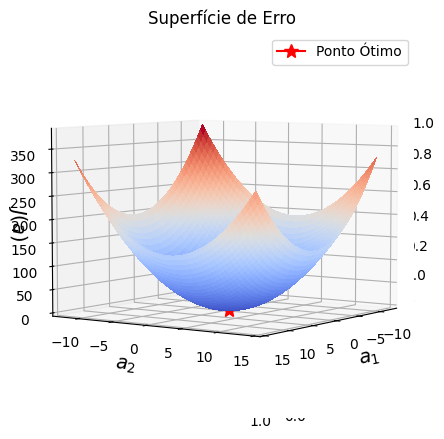

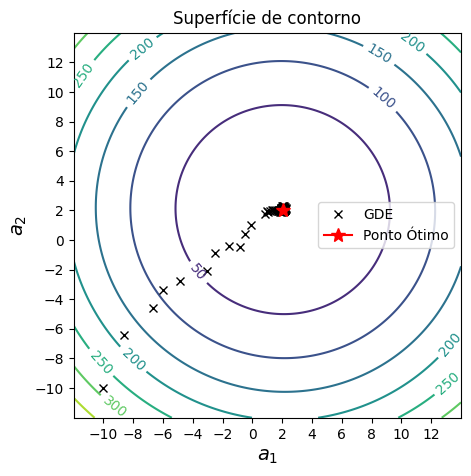

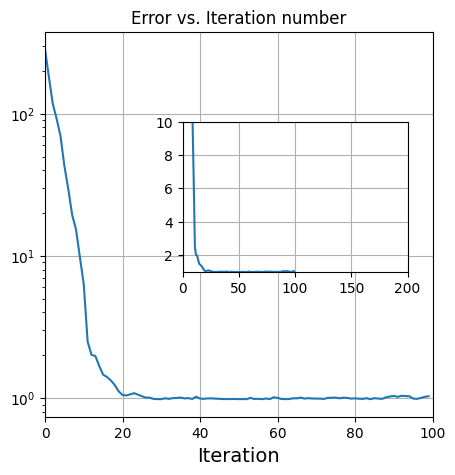

<ipython-input-11-d0fe2d04ddce>:216: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


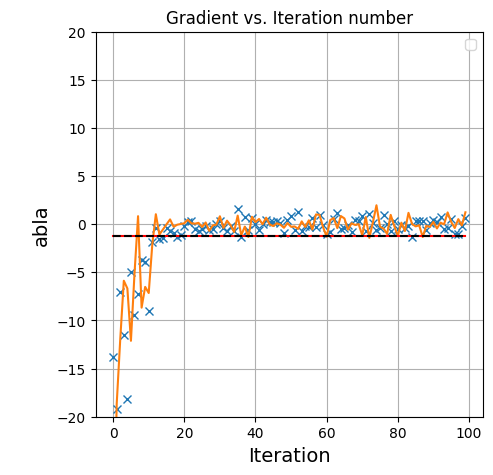

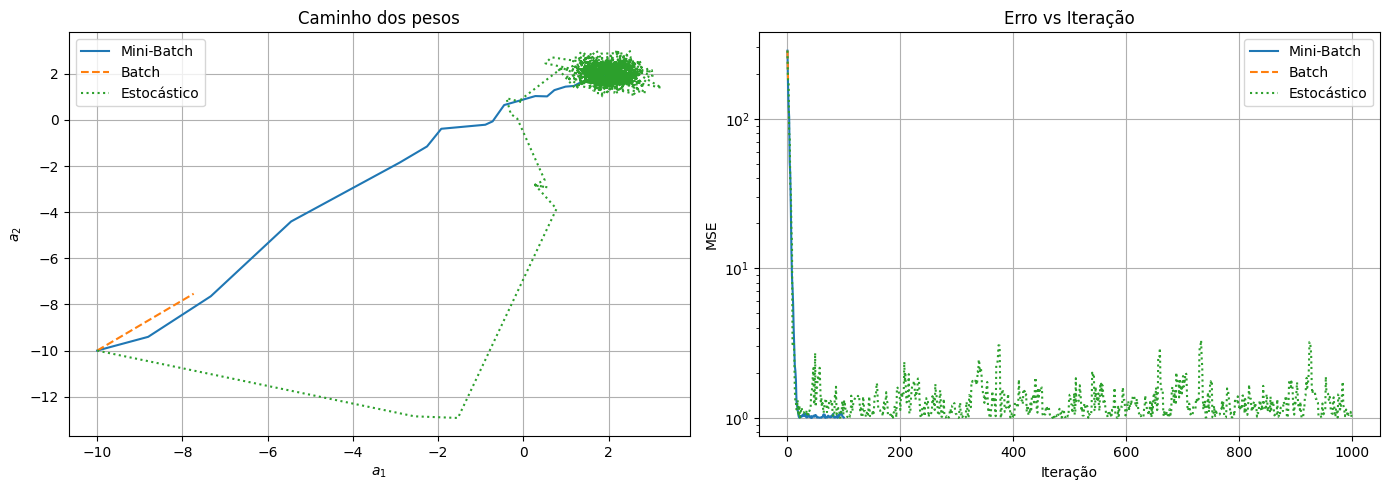

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import random


seed = 1234
np.random.seed(seed) # Reseta os geradores de números aleatórios da biblioteca numpy

random.seed(seed) # Para embaralhar os índices da base de dados sempre da mesma forma


def eq_normal_without_intercept_plano (x1, x2, y_noisy):
  X = np.c_[x1, x2]
  a_numpy_plano = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y_noisy)
  y_pred_plano = X.dot(a_numpy_plano)

  Je_optimum_plano = (1/len(y_noisy))*np.sum(np.power((y_noisy-y_pred_plano),2))

  return a_numpy_plano, y_pred_plano, Je_optimum_plano


def gradiente_descendente_mini_batch (x1, x2, y_noisy, alpha, n_epochs, mb_size):

  N = len(y_noisy)

  X = np.c_[x1, x2]

  a_mb = np.array([-10.0, -10.0]).reshape(2,1)
  # n_epochs*N refere-se à quantidade de épocas vezes o número de iterações por época, resultando na quantidade de iterações para formar as matrizes/vetores seguintes
  a_hist_mb = np.zeros((2, n_epochs*(N//mb_size)+1))
  a_hist_mb[:,0] = a_mb.reshape(2,)
  # print("a_hist = ", a_hist_estocastico)
  # print("shape = ", np.shape(a_hist_estocastico))
  J_gd_mb = np.zeros(n_epochs*(N//mb_size)+1)

  y_hat = X.dot(a_mb)
  J_gd_mb[0]= (1.0/N)*np.sum(np.power((y_noisy - y_hat),2)) # DÚVIDA NO CÔMPUTO DO ERRO. DIVIDE-SE POR N?

  grad_hist_mb = np.zeros((2, n_epochs*(N//mb_size)))

  iteration = 0

  for epoch_estocastico in range(n_epochs):
    shuffled_indexes = random.sample(range(0, N), N)

    for i in range(0, N, mb_size):
      random_index = shuffled_indexes[i:i+mb_size]
      xi = X[random_index]
      yi = y_noisy[random_index]

      # Atualização dos pesos
      gradients = -(2.0 / mb_size) * xi.T.dot(yi - xi.dot(a_mb))
      a_mb = a_mb - alpha * gradients

      # Armazena o histórico de gradientes e pesos, agora indexados pela iteração total
      grad_hist_mb[:, iteration] = gradients.reshape(2,)
      a_hist_mb[:, iteration + 1] = a_mb.reshape(2,)

      # Cálculo do MSE por iteração
      y_hat = X.dot(a_mb)
      J_gd_mb[iteration + 1] = (1.0 / N) * np.sum(np.power((y_noisy - y_hat), 2))

      # Incrementa o contador de iteração
      iteration += 1

      # # Armazena o histórico de gradientes e atributos
      # grad_hist_mb[:, iteration+i] = gradients.reshape(2,)
      # a_hist_mb[:, iteration+i+1] = a_mb.reshape(2,)
  #     print(np.shape(a_hist_estocastico))

  #   print(np.shape(a_hist_estocastico))

  # print(a_hist_estocastico)
  return a_mb, J_gd_mb, a_hist_mb, grad_hist_mb



def gradiente_descendente_batch(x1, x2, y_noisy, alpha, n_epochs):
    N = len(y_noisy)
    X = np.c_[x1, x2]
    a_batch = np.array([-10.0, -10.0]).reshape(2,1)
    a_hist_batch = np.zeros((2, n_epochs+1))
    a_hist_batch[:,0] = a_batch.reshape(2,)
    J_gd_batch = np.zeros(n_epochs+1)
    y_hat = X.dot(a_batch)
    J_gd_batch[0] = (1.0/N)*np.sum(np.power((y_noisy - y_hat),2))

    for epoch in range(n_epochs):
        gradients = -(2.0 / N) * X.T.dot(y_noisy - X.dot(a_batch))
        a_batch = a_batch - alpha * gradients
        a_hist_batch[:, epoch+1] = a_batch.reshape(2,)
        y_hat = X.dot(a_batch)
        J_gd_batch[epoch+1] = (1.0/N)*np.sum(np.power((y_noisy - y_hat),2))

    return a_batch, J_gd_batch, a_hist_batch

def gradiente_descendente_estocastico(x1, x2, y_noisy, alpha, n_epochs):
    N = len(y_noisy)
    X = np.c_[x1, x2]
    a_sgd = np.array([-10.0, -10.0]).reshape(2,1)
    a_hist_sgd = np.zeros((2, n_epochs*N+1))
    a_hist_sgd[:,0] = a_sgd.reshape(2,)
    J_gd_sgd = np.zeros(n_epochs*N+1)
    y_hat = X.dot(a_sgd)
    J_gd_sgd[0] = (1.0/N)*np.sum(np.power((y_noisy - y_hat),2))

    iteration = 0
    for epoch in range(n_epochs):
        shuffled_indexes = random.sample(range(0, N), N)
        for i in range(N):
            idx = shuffled_indexes[i]
            xi = X[idx].reshape(1, -1)
            yi = y_noisy[idx]
            gradients = -(2.0) * xi.T.dot(yi - xi.dot(a_sgd))
            a_sgd = a_sgd - alpha * gradients
            iteration += 1
            a_hist_sgd[:, iteration] = a_sgd.reshape(2,)
            y_hat = X.dot(a_sgd)
            J_gd_sgd[iteration] = (1.0/N)*np.sum(np.power((y_noisy - y_hat),2))

    return a_sgd, J_gd_sgd, a_hist_sgd


# CÁLCULO DA SUPERFÍCIE DE ERRO
def error_surface_3D(x1, x2, y_noisy, a_numpy_plano, Je_optimum_plano):
  M = 200
  # a1 e a2 devem ser vetores linearmente espaçados com o valor médio igual ao valor ótimo dos respectivos atributos. Se a função objetivo for, por exemplo: y = x1 + x2 (a1 e a2 iguais a 1.0)
  a1 = np.linspace(-12.0, 14.0, M) # No caso, a1_opt = 1.0. Então, têm-se três valores abaixo e três valores acima de 1.0 (é o valor médio)
  a2 = np.linspace(-12.0, 14.0, M) # Mesmo caso do a2_opt. O menor e o maior devem condizer com a excursão dos atributos da função objetivo

  A1, A2 = np.meshgrid(a1, a2)

  J = np.zeros((M,M))
  for iter1 in range(0,M):
    for iter2 in range(0,M):
      y_hat = A1[iter1, iter2]*x1 + A2[iter1, iter2]*x2 # ***** MUITA ATENÇÃO AQUI ***** SERÁ ALTERADA DE ACORDO COM A FUNÇÃO OBJETIVO
      J[iter1, iter2] = (1/len(y_noisy))*np.sum(np.power((y_noisy - y_hat),2))

  return A1, A2, J


# PLOT DA SUPERFÍCIE DE ERRO
def error_surface_3D_plot (A1, A2, J, a_numpy_plano, Je_optimum_plano):
  fig = plt.figure(figsize=(5,5))
  plt.subplot(projection='3d')
  ax = fig.add_subplot(111, projection='3d')

  surf = ax.plot_surface(A1, A2, J, cmap=cm.coolwarm, linewidth=0, antialiased=False)
  plt.plot([a_numpy_plano[0,0]],[a_numpy_plano[1,0]], [Je_optimum_plano], c = 'r', marker = '*', markersize = 10, label = 'Ponto Ótimo')
  ax.set_xlabel('$a_1$', fontsize=14)
  ax.set_ylabel('$a_2$', fontsize=14)
  ax.set_zlabel('$J(a)$', fontsize=14)


  ax.zaxis.labelpad = -7
  plt.title("Superfície de Erro")
  ax.view_init(5,35)

  plt.legend()
  plt.show()


# PLOT DA SUPERFÍCIE DE CONTORNO
def error_surface_3D_contour (A1, A2, J, a_numpy_plano):
  fig_ctr = plt.figure(figsize = (5,5))

  cp = plt.contour(A1, A2, J)
  plt.clabel(cp, inline=1, fontsize=10)
  plt.xlabel('$a_1$', fontsize=14)
  plt.ylabel('$a_2$', fontsize=14)

  plt.title('Superfície de contorno')
  plt.plot(a_hist_mb[0,:], a_hist_mb[1,:], 'kx', label='GDE')
  plt.plot([a_numpy_plano[0,0]],[a_numpy_plano[1,0]], c = 'r', marker = '*', markersize = 10, label = 'Ponto Ótimo')
  plt.xticks(np.arange(-10, 14, step=2.0)) # ***** Ajustado de acordo com os limites de a1 *****
  plt.yticks(np.arange(-10, 14, step=2.0)) # ***** Ajustado de acordo com os limites de a2 *****
  plt.legend()
  plt.show()


def MSE_vs_iterations_plot (n_epochs, J_gd_mb, N, mb_size):
  fig = plt.figure(figsize=(5,5))

  plt.plot(np.arange(0, n_epochs*(N // mb_size)), J_gd_mb[0:n_epochs*(N // mb_size)])
  plt.xlim((0, n_epochs*(N // mb_size)))
  plt.yscale('log')
  plt.xlabel('Iteration', fontsize=14)
  plt.ylabel('', fontsize=14)
  plt.title('Error vs. Iteration number')
  plt.grid()

  left, bottom, width, height = [0.4, 0.4, 0.45, 0.3]
  ax1 = fig.add_axes([left, bottom, width, height])
  ax1.plot(np.arange(0, n_epochs*(N // mb_size)), J_gd_mb[0:n_epochs*(N // mb_size)])
  ax1.set_xlim(0, 200)
  ax1.set_ylim(1, 10)
  ax1.grid()

  #plt.savefig("error_vs_iteration_sgd.png", dpi=600)
  plt.show()


def grad_vs_iteration (grad_hist, n_epochs, N, mb_size):
  fig = plt.figure(figsize=(5,5))

  plt.plot(np.arange(0, n_epochs*(N // mb_size)), grad_hist[0,:], 'x', label='')
  plt.plot(np.arange(0, n_epochs*(N // mb_size)), grad_hist[1,:], label='')
  plt.plot(np.arange(0, n_epochs*(N // mb_size)), np.mean(grad_hist[1,:])*np.ones(n_epochs*(N // mb_size)), 'r', label='')
  plt.plot(np.arange(0, n_epochs*(N // mb_size)), np.mean(grad_hist[0,:])*np.ones(n_epochs*(N // mb_size)), 'k--', label='')
  plt.ylim([-20, 20])
  plt.xlabel('Iteration', fontsize=14)
  plt.ylabel('\nabla', fontsize=14)
  plt.title('Gradient vs. Iteration number')
  plt.legend()
  plt.grid()
  plt.show()


n_epochs = 1
alpha = 0.01  # tentei 0.01, 0.05, 0.2

# Number of pairs features/label.
N = 1000

# Attributes (vetores coluna).
x1 = np.random.randn(N, 1)
x2 = np.random.randn(N, 1)

# True function.
y = 2*x1 + 2*x2

# Noise (vetor coluna).
w = np.random.randn(N, 1)

# Labels (rótulos).
y_noisy = y + w


a_numpy_plano, y_pred_plano, Je_optimum_plano = eq_normal_without_intercept_plano(x1, x2, y_noisy)
# plot_objetivo_observavel_pred_3D (x1, x2, y, y_noisy, y_pred_plano, a_numpy_plano)
a_mb, J_gd_mb, a_hist_mb, grad_hist_mb = gradiente_descendente_mini_batch(x1, x2, y_noisy, alpha = 0.1, n_epochs = 1, mb_size = 10)
A1, A2, J = error_surface_3D(x1, x2, y_noisy, a_numpy_plano, Je_optimum_plano)
error_surface_3D_plot (A1, A2, J, a_numpy_plano, Je_optimum_plano)
error_surface_3D_contour (A1, A2, J, a_numpy_plano)
MSE_vs_iterations_plot (n_epochs, J_gd_mb, N, mb_size = 10)
grad_vs_iteration (grad_hist_mb, n_epochs, N, mb_size = 10)







# Plotar resultados
def plotar_comparacoes(a_hist_mb, a_hist_batch, a_hist_sgd, J_gd_mb, J_gd_batch, J_gd_sgd):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # Contorno a1 vs a2
    axs[0].plot(a_hist_mb[0,:], a_hist_mb[1,:], label='Mini-Batch', linestyle='-')
    axs[0].plot(a_hist_batch[0,:], a_hist_batch[1,:], label='Batch', linestyle='--')
    axs[0].plot(a_hist_sgd[0,:], a_hist_sgd[1,:], label='Estocástico', linestyle=':')
    axs[0].set_xlabel('$a_1$')
    axs[0].set_ylabel('$a_2$')
    axs[0].set_title('Caminho dos pesos')
    axs[0].legend()
    axs[0].grid(True)

    # Erro vs Iteração
    axs[1].plot(J_gd_mb, label='Mini-Batch', linestyle='-')
    axs[1].plot(J_gd_batch, label='Batch', linestyle='--')
    axs[1].plot(J_gd_sgd, label='Estocástico', linestyle=':')
    axs[1].set_yscale('log')
    axs[1].set_xlabel('Iteração')
    axs[1].set_ylabel('MSE')
    axs[1].set_title('Erro vs Iteração')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

# Gerar dados
def gerar_dados(N=1000):
    x1 = np.random.randn(N, 1)
    x2 = np.random.randn(N, 1)
    w = np.random.randn(N, 1)
    y = 2*x1 + 2*x2
    y_noisy = y + w
    return x1, x2, y_noisy

# Exemplo de execução
n_epochs = 1
alpha = 0.1
mb_size = 10
x1, x2, y_noisy = gerar_dados()

_, _, a_hist_mb, _ = gradiente_descendente_mini_batch(x1, x2, y_noisy, alpha, n_epochs, mb_size)
_, _, a_hist_batch = gradiente_descendente_batch(x1, x2, y_noisy, alpha, n_epochs)
_, _, a_hist_sgd = gradiente_descendente_estocastico(x1, x2, y_noisy, alpha, n_epochs)

_, J_gd_mb, _, _ = gradiente_descendente_mini_batch(x1, x2, y_noisy, alpha, n_epochs, mb_size)
_, J_gd_batch, _ = gradiente_descendente_batch(x1, x2, y_noisy, alpha, n_epochs)
_, J_gd_sgd, _ = gradiente_descendente_estocastico(x1, x2, y_noisy, alpha, n_epochs)

plotar_comparacoes(a_hist_mb, a_hist_batch, a_hist_sgd, J_gd_mb, J_gd_batch, J_gd_sgd)


# Comparando os resultados.
Comparando os três métodos, o Batch Gradient Descent apresenta a maior estabilidade, convergindo diretamente ao ótimo com poucas atualizações, mas é mais lento em datasets grandes. O Mini-Batch Gradient Descent alcança um bom equilíbrio entre estabilidade e velocidade, realizando atualizações frequentes que resultam em um caminho suave até o ótimo. Já o Stochastic Gradient Descent (SGD) é o mais rápido em termos de atualizações, mas o menos estável, apresentando muitas oscilações no erro e no caminho dos pesos, o que pode dificultar atingir exatamente o ponto ótimo.